# Exercício:

## 01 – Importe o .csv utilizado no exercício 1 da aula 13 e instancie um objeto da classe DataFrame. Busque no GenBank do NCBI, a sequência aminoacídica referente à cada gene, baixe o arquivo FASTA, e importe para o Python. Instancie um objeto da classe DataFrame onde as linhas serão os genes e as colunas, a sigla, o código de referência e a sequência aminoacídica.

https://1drv.ms/v/c/808ebfd9a0d86213/IQCLY6g2vuPjQr-7RxF_QZK0AWue-PxKWmQ8QlMEtwIh2WA?e=qBwOpD

In [19]:
import pandas as pd
import numpy as np
from Bio import Entrez
import time
import matplotlib.pyplot as plt
import seaborn as sns
import statistics as st

In [2]:
# Importando o arquivo
df_genes = pd.read_csv('df_genes.csv', index_col='Unnamed: 0')
df_genes

,Número de Caracteres,Dois Primeiros Caracteres,Quantidade de 'a's,Presença de Caracteres 'hu'
SRY,3,SR,0,False
Cetn-1,6,Ce,0,False
PFR2,4,PF,0,False
HER2,4,HE,0,False
GFP,3,GF,0,False


In [3]:
# Criando as colunas para acessar os arquivos FASTA dos genes por API
df_genes['id_entrez'] = [
    "NM_003140.3",
    "NM_004066.3",
    "XM_842234.1",
    "NM_004448.4",
    "XM_067079949.1"
]

df_genes['id_protein'] = [
    "NP_003131.1",
    "NP_004057.1",
    "XP_847327.1",
    "NP_004439.2",
    "XP_066936050.1"
]

df_genes

# Obs.: Para o gene PFR2 e GFP não havia MANE select. Como nos exercícios vai precisar apenas do
# id_protein, colocou o transcript accession equivalente para esses dois genes.
# Obs.2: Não tinha GFP de Aequorea victoria no NCBI. Trocou para GFP like (GFP1) de Clytia hemisphaerica.

,Número de Caracteres,Dois Primeiros Caracteres,Quantidade de 'a's,Presença de Caracteres 'hu',id_entrez,id_protein
SRY,3,SR,0,False,NM_003140.3,NP_003131.1
Cetn-1,6,Ce,0,False,NM_004066.3,NP_004057.1
PFR2,4,PF,0,False,XM_842234.1,XP_847327.1
HER2,4,HE,0,False,NM_004448.4,NP_004439.2
GFP,3,GF,0,False,XM_067079949.1,XP_066936050.1


In [4]:
def salvar_fasta_gene(id_protein: str, nome_gene: str) -> None:
    '''
        Salva a sequência de um gene em formato FASTA.
            Args:
                id_protein (str): ID do gene no GenBank.
                nome_gene (str): Nome do gene para salvar o arquivo.
            Returns:
                None
    '''
    # Necessário informar seu email
    Entrez.email = "rafaeluveiga@gmail.com"

    # Busca a sequência (ex: um ID do GenBank)
    handle = Entrez.efetch(db="protein", id=id_protein, rettype="fasta", retmode="text")
    record = handle.read()
    handle.close()

    # Salva o arquivo
    with open(f"./{nome_gene}.fasta", "w") as f:
        fasta = f.write(record)
    
    return None

In [28]:
for index in df_genes.index:
    id_gene = df_genes.loc[index, "id_protein"]
    nome_gene = index 
    salvar_fasta_gene(nome_gene=nome_gene, id_protein=id_gene)
    time.sleep(10)  # Para evitar sobrecarga no servidor do NCBI
    print(nome_gene, id_gene)

URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: self signed certificate in certificate chain (_ssl.c:1007)>

Por alguma razão no ambiente local eu não consegui rodar as funções e baixar os arquivos FASTA (mesmo com o DataFrame com os genes do professor). Aparentemente foi algum erro de certificado que não foi possível resolver tentando atualizá-lo (!pip install --upgrade certifi). Por isso, rodei exatamente estes códigos no Colab para fazer o download. Subi o notebook do colab para o git hub em conjunto (Lista15_DisciplinaPython_Colab.ipynb)

Instancie um objeto da classe DataFrame onde as linhas serão os genes e as colunas, a sigla, o código de referência e a sequência aminoacídica.

In [4]:
# Criando o DataFrame
descr_gene = {}
for gene in df_genes.index:
    caminho = f"./{gene}.fasta"
    with open(caminho, 'r') as file:
        data = file.read()
        data = data.split('\n')
        cod = data[0].split(" ")[0]
        seq = ''.join(data[1:-2])
        descr_gene[gene] = {"gene": gene, "cod": cod, "seq": seq}
df = pd.DataFrame.from_dict(descr_gene, orient='index')


# Ajustando os nomes do index para que seja o nome completo do gene
df.index = [
    "Sex Determining Region Y",
    "Centrin 1",
    "Paraflagellar Rod Protein",
    "Erb-b2 Receptor Tyrosine Kinase 2",
    "Green Fluorescent Protein-like"
    ]

# Visualizando o DataFrame
df.head()

,gene,cod,seq
Sex Determining Region Y,SRY,>NP_003131.1,MQSYASAMLSVFNSDDYSPAVQENIPALRRSSSFLCTESCNSKYQC...
Centrin 1,Cetn-1,>NP_004057.1,MASGFKKPSAASTGQKRKVAPKPELTEDQKQEVREAFDLFDVDGSG...
Paraflagellar Rod Protein,PFR2,>XP_847327.1,MSGKEVEGVVSPADQQQPAVPEVTDITLEAARKQKIHNLKLKTACL...
Erb-b2 Receptor Tyrosine Kinase 2,HER2,>NP_004439.2,MELAALCRWGLLLALLPPGAASTQVCTGTDMKLRLPASPETHLDML...
Green Fluorescent Protein-like,GFP,>XP_066936050.1,MASAGALLLNQRVPFIMELDAEVNGIRFAVRGKGTGDATTGIIDTK...


## 02 – Importe o .csv as informações dos aminoácidos e instancie um objeto da classe DataFrame. Obtenha a frequência absoluta de cada um dos aminoácidos para cada um dos genes. Instancie um objeto da classe DataFrame com as informações.

In [5]:
fas_gene1 = {}
for aa in df.iloc[0,2]:
    fas_gene1[aa] = df.iloc[0,2].count(aa)

fas_gene2 = {}
for aa in df.iloc[0,2]:
    fas_gene2[aa] = df.iloc[1,2].count(aa)

fas_gene3 = {}
for aa in df.iloc[0,2]:
    fas_gene3[aa] = df.iloc[2,2].count(aa)

fas_gene4 = {}
for aa in df.iloc[0,2]:
    fas_gene4[aa] = df.iloc[3,2].count(aa)

fas_gene5 = {}
for aa in df.iloc[0,2]:
    fas_gene5[aa] = df.iloc[4,2].count(aa)

dic_genes = {
    "SRY": fas_gene1,
    "Cetn-1": fas_gene2,
    "PFR2": fas_gene3,
    "HER2": fas_gene4,
    "GFP": fas_gene5
}

df_aa = pd.DataFrame(dic_genes).sort_index()
df_aa

,SRY,Cetn-1,PFR2,HER2,GFP
A,15,12,53,83,17
C,6,0,7,59,5
D,9,16,34,65,13
E,12,24,79,77,13
F,5,10,14,35,10
G,4,11,18,101,22
H,5,0,18,35,8
I,4,7,29,44,14
K,15,21,59,39,16
L,16,13,59,138,17


In [8]:
# Trocando o código do aminoácido pelo nome extenso
df_aa.index = ["Alanina", "Cisteína", "Aspartato", "Glutamato", "Fenilalanina",
               "Glicina", "Histidina", "Isoleucina", "Lisina", "Leucina",
               "Metionina", "Asparagina", "Prolina", "Glutamina", "Arginina",
               "Serina", "Treonina", "Valina", "Triptofano", "Tirosina"]
df_aa

,SRY,Cetn-1,PFR2,HER2,GFP
Alanina,15,12,53,83,17
Cisteína,6,0,7,59,5
Aspartato,9,16,34,65,13
Glutamato,12,24,79,77,13
Fenilalanina,5,10,14,35,10
Glicina,4,11,18,101,22
Histidina,5,0,18,35,8
Isoleucina,4,7,29,44,14
Lisina,15,21,59,39,16
Leucina,16,13,59,138,17


## 03 – Qual é o número de Valinas presentes em cada um dos genes? Qual o gene tem o maior número?

In [17]:
print(
    "Qual o nº de Valinas em cada gene?", "\n",
    df_aa.loc["Valina"], "\n\n",
    "Qual gene tem o maior número?", "\n",
    df_aa.loc["Valina"].idxmax()
)

Qual o nº de Valinas em cada gene? 
 SRY        7
Cetn-1     8
PFR2      36
HER2      83
GFP       18
Name: Valina, dtype: int64 

 Qual gene tem o maior número? 
 HER2


## 04 – Qual a média, a mediana e a moda da frequência absoluta de Serina presente nos genes?

In [24]:
df_aa.loc["Serina"]

SRY       21
Cetn-1     9
PFR2      26
HER2      73
GFP       11
Name: Serina, dtype: int64

In [28]:
print(
    "Média =", st.mean(df_aa.loc["Serina"]), "\n"
    "Mediana =", st.median(df_aa.loc["Serina"]), "\n"
    "Moda =", st.mode(df_aa.loc["Serina"]),
)

Média = 28 
Mediana = 21 
Moda = 21


## 05 – Gere um histograma, contendo a média e a mediana, com o número de Serinas por gene.

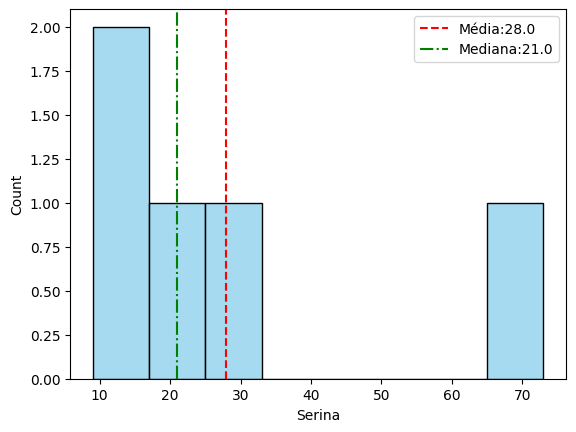

In [99]:
media = st.mean(df_aa.loc["Serina"])
mediana = st.median(df_aa.loc["Serina"])

sns.histplot(
    x = df_aa.loc["Serina"],
    bins = 8,
    color="skyblue"
)
plt.axvline(media, color="red", linestyle="--", label=f'Média:{media:.1f}')
plt.axvline(mediana, color="green", linestyle="-.", label=f'Mediana:{mediana:.1f}')
plt.legend()
plt.show()

## 06 – Defina uma função que receba o nome de um aa qualquer e retorne o mesmo resultado do exercício anterior.

In [109]:
def hist_aa(data:pd.DataFrame, aa:str) -> None:
    media = st.mean(data.loc[aa])
    mediana = st.median(data.loc[aa])
    sns.histplot(
    x = data.loc[aa],
    bins = 8,
    color="skyblue"
    )
    plt.axvline(media, color="red", linestyle="--", label=f'Média:{media:.1f}')
    plt.axvline(mediana, color="green", linestyle="-.", label=f'Mediana:{mediana:.1f}')
    plt.legend()
    plt.show()
    return None

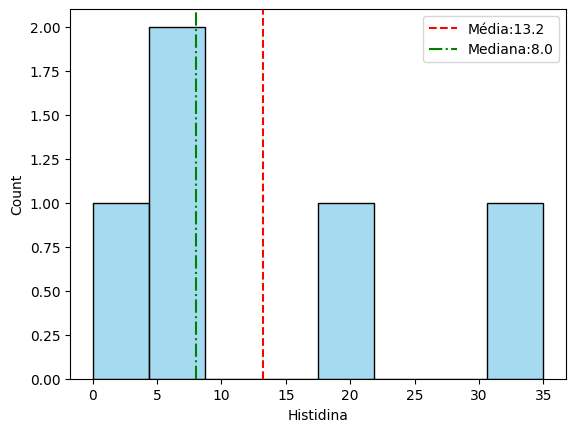

In [ ]:
# Testando a função
hist_aa(data=df_aa, aa="Histidina")

## 07 – Retorne os gráficos dos aa Glutamina, Glicina, Lisina e Valina. Qual possuí menor diferença entre média e mediana?

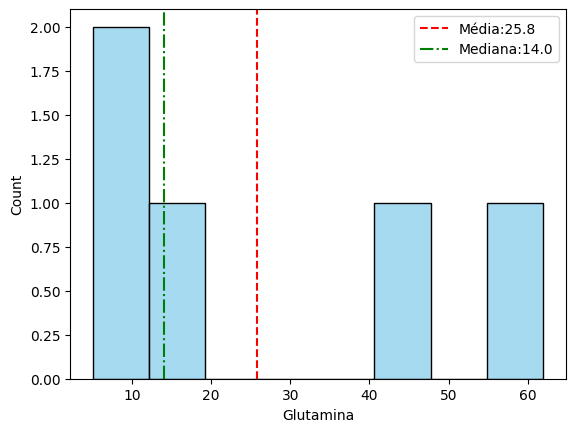

In [111]:
hist_aa(data=df_aa, aa="Glutamina")

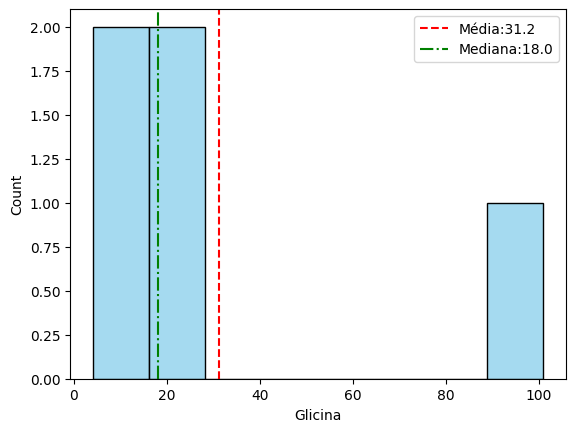

In [112]:
hist_aa(data=df_aa, aa="Glicina")

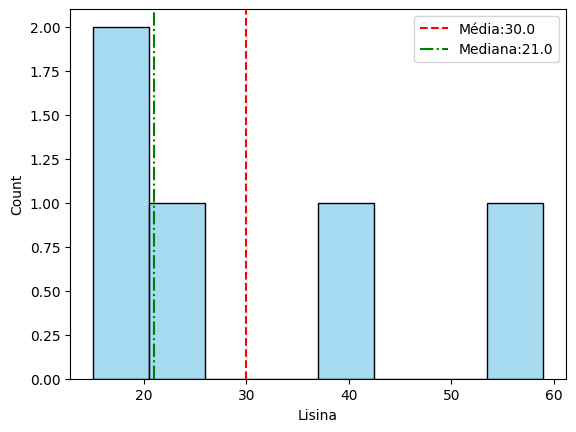

In [113]:
hist_aa(data=df_aa, aa="Lisina")

In [121]:
dif_glutamina = st.mean(df_aa.loc["Glutamina"]) - st.median(df_aa.loc["Glutamina"])
dif_glicina = st.mean(df_aa.loc["Glicina"]) - st.median(df_aa.loc["Glicina"])
dif_lisina = st.mean(df_aa.loc["Lisina"]) - st.median(df_aa.loc["Lisina"])

print("Qual possui a menor diferença entre média e mediana?")
if dif_glutamina == min(dif_glutamina, dif_glicina, dif_lisina):
    print("Glutamina")
elif dif_glicina == min(dif_glutamina, dif_glicina, dif_lisina):
    print("Glicina")
else:
    print("Lisina")

Qual possui a menor diferença entre média e mediana?
Lisina


## 08 – Dentre os três primeiros genes, qual é a média e a mediana de Cisteína?

In [129]:
print(
    "Cisteína (Três primeiros genes):\n"
    "Média =", st.mean(df_aa.iloc[1,:3]), "\n",
    "Mediana =", st.median(df_aa.iloc[1,:3])
)

Cisteína (Três primeiros genes):
Média = 4.333333333333333 
 Mediana = 6


## 09 – Analisando o valor médio de aa em cada um dos genes, qual seria o maior gene (maior número médio de aa)?

In [171]:
print("Gene com maior número médio de aa =", df_aa.mean().idxmax())

Gene com maior número médio de aa = HER2


## 10 – Olhando o valor médio de aa em cada um dos genes, qual seria o menor gene (menor número médio de aa)?

In [174]:
print("Gene com menor número médio de aa =", df_aa.mean().idxmin())

Gene com menor número médio de aa = Cetn-1
